## 0. Setup Lingkungan & Konfigurasi
Menyiapkan pustaka Python yang dibutuhkan dan mengunduh data stopwords NLTK.


In [1]:
# Deskripsi: Menginstal pustaka Python yang diperlukan untuk deteksi fake review
!pip install scikit-learn pandas numpy matplotlib seaborn nltk vaderSentiment imbalanced-learn statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Deskripsi: Menginstal pustaka Python yang diperlukan untuk deteksi fake review
# Install dependencies (uncomment di Colab)
# !pip install scikit-learn pandas numpy matplotlib seaborn nltk vaderSentiment imbalanced-learn statsmodels

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Sklearn — Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Sklearn — Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Statistical Test
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import pointbiserialr

# NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print(" Semua library berhasil diimport!")


 Semua library berhasil diimport!


In [3]:
# ── CONFIG ──────────────────────────────────────────────────
# Ubah DATA_PATH sesuai lokasi file kamu
# Contoh Google Colab: '/content/fake_reviews_dataset_1.csv'
# Contoh lokal       : 'data/fake_reviews_dataset_1.csv'



DATA_PATH   = 'content/data/fake reviews dataset_1.csv'
OUTPUT_DIR  = 'outputs'
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f" Output dir  : {OUTPUT_DIR}/")
print(f" Figures dir : {FIGURES_DIR}/")
print(f" Results dir : {RESULTS_DIR}/")


 Output dir  : outputs/
 Figures dir : outputs\figures/
 Results dir : outputs\results/


# 2. Dataset Exploration (EDA)
Memuat dataset, melakukan pengecekan kualitas data (nilai kosong dan duplikasi), serta menganalisis statistik deskriptif panjang ulasan.


In [4]:
# Deskripsi: Fungsi untuk memuat dataset ulasan, membersihkan data kosong, dan mengubah label menjadi biner
def load_and_clean(path):
    """Load dataset, filter valid labels OR/CG, harmonize ke binary."""
    df = pd.read_csv(DATA_PATH, sep=';', usecols=['category', 'rating', 'label', 'text_'])

    # Filter: hanya label valid
    df = df[df['label'].isin(['OR', 'CG'])].copy()
    df = df.dropna(subset=['text_'])
    df['text_'] = df['text_'].astype(str).str.strip()
    df = df[df['text_'].str.len() > 0].reset_index(drop=True)

    # Binary label: OR=0 (genuine), CG=1 (fake)
    df['label_bin'] = df['label'].map({'OR': 0, 'CG': 1})
    return df

df = load_and_clean(DATA_PATH)

print(f"{'='*50}")
print(f"  Total rows    : {len(df):,}")
print(f"  OR Genuine=0  : {(df['label_bin']==0).sum():,} ({(df['label_bin']==0).mean()*100:.1f}%)")
print(f"  CG Fake=1     : {(df['label_bin']==1).sum():,} ({(df['label_bin']==1).mean()*100:.1f}%)")
print(f"  Null values   : {df.isnull().sum().sum()}")
print(f"{'='*50}")


  Total rows    : 40,094
  OR Genuine=0  : 20,164 (50.3%)
  CG Fake=1     : 19,930 (49.7%)
  Null values   : 0


In [5]:
# Deskripsi: Menampilkan sampel beberapa baris ulasan pertama dari dataset
# Preview dataset
print("Sample data:")
df[['category', 'rating', 'label', 'label_bin', 'text_']].head(6)


Sample data:


,category,rating,label,label_bin,text_
0,Home_and_Kitchen_5,5.0,CG,1,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,1,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,1,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,1,Very nice set. Good quality. We have had the s...
5,Home_and_Kitchen_5,3.0,CG,1,I WANTED DIFFERENT FLAVORS BUT THEY ARE NOT.


In [6]:
# Deskripsi: Memeriksa kualitas data dengan mendeteksi nilai kosong dan ulasan duplikat
# ── KUALITAS DATA & STATISTIK DESKRIPTIF ──────────────────
print('=== PEMERIKSAAN NILAI KOSONG ===')
print(df.isnull().sum())
print('\n=== PEMERIKSAAN DUPLIKASI DATA ===')
duplicate_count = df.duplicated(subset=['text_']).sum()
print(f'Jumlah ulasan dengan teks duplikat: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)')

# Statistik dasar panjang kata per label
df['word_count'] = df['text_'].apply(lambda x: len(str(x).split()))
print('\n=== STATISTIK DESKRIPTIF PANJANG KATA PER LABEL ===')
print(df.groupby('label')['word_count'].describe().round(2))


=== PEMERIKSAAN NILAI KOSONG ===
category     0
rating       0
label        0
text_        0
label_bin    0
dtype: int64

=== PEMERIKSAAN DUPLIKASI DATA ===
Jumlah ulasan dengan teks duplikat: 85 (0.21%)

=== STATISTIK DESKRIPTIF PANJANG KATA PER LABEL ===
         count   mean    std  min   25%   50%   75%    max
label                                                     
CG     19930.0  50.67  53.78  1.0  17.0  29.0  61.0  313.0
OR     20164.0  49.99  46.82  1.0  20.0  34.0  63.0  351.0


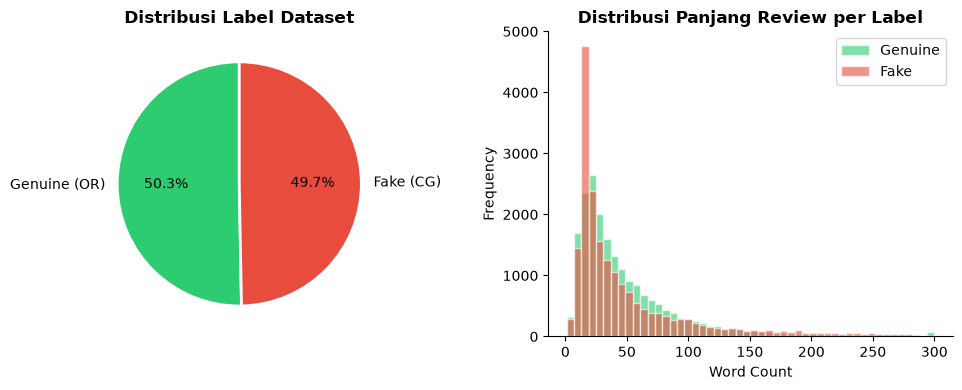

 Saved: dataset_distribution.png


In [7]:
# Deskripsi: Visualisasi grafik untuk melihat distribusi label kelas dan panjang ulasan
# Distribusi label — visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
label_counts = df['label'].value_counts()
axes[0].pie(label_counts.values, labels=['Genuine (OR)', 'Fake (CG)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribusi Label Dataset', fontweight='bold')

# Word count distribution per label
df['word_count'] = df['text_'].str.split().str.len()
for label, color, name in [(0,'#2ecc71','Genuine'), (1,'#e74c3c','Fake')]:
    subset = df[df['label_bin']==label]['word_count'].clip(0, 300)
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribusi Panjang Review per Label', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: dataset_distribution.png")


### 2.2 Analisis N-Gram Dominan
Mengekstrak Unigram dan Bigram paling sering muncul pada masing-masing kategori ulasan sebelum preprocessing teks.


In [8]:
# Deskripsi: Fungsi untuk mengekstrak unigram dan bigram dominan dalam teks ulasan
from collections import Counter
import nltk
nltk.download('punkt', quiet=True)

def get_top_ngrams(texts, n=1, top_k=15):
    """Mendapatkan N-Gram teratas dari teks."""
    stop_words = set(stopwords.words('english'))
    ngrams_list = []
    for text in texts:
        words = [w.lower() for w in re.findall(r'\b[a-zA-Z]{2,}\b', text)]
        words = [w for w in words if w not in stop_words]
        if n == 1:
            ngrams_list.extend(words)
        else: 
            bg = list(zip(words[:-1], words[1:]))
            bg_str = [f"{w1} {w2}" for w1, w2 in bg]
            ngrams_list.extend(bg_str)
    counter = Counter(ngrams_list)
    return counter.most_common(top_k)

# Ambil contoh teks Genuine vs Fake
genuine_texts = df[df['label_bin'] == 0]['text_'].values
fake_texts_eda = df[df['label_bin'] == 1]['text_'].values

# Dapatkan unigram & bigram
genuine_unigrams = get_top_ngrams(genuine_texts, n=1)
fake_unigrams = get_top_ngrams(fake_texts_eda, n=1)
genuine_bigrams = get_top_ngrams(genuine_texts, n=2)
fake_bigrams = get_top_ngrams(fake_texts_eda, n=2)

print(" N-Gram Extraction selesai!")


 N-Gram Extraction selesai!


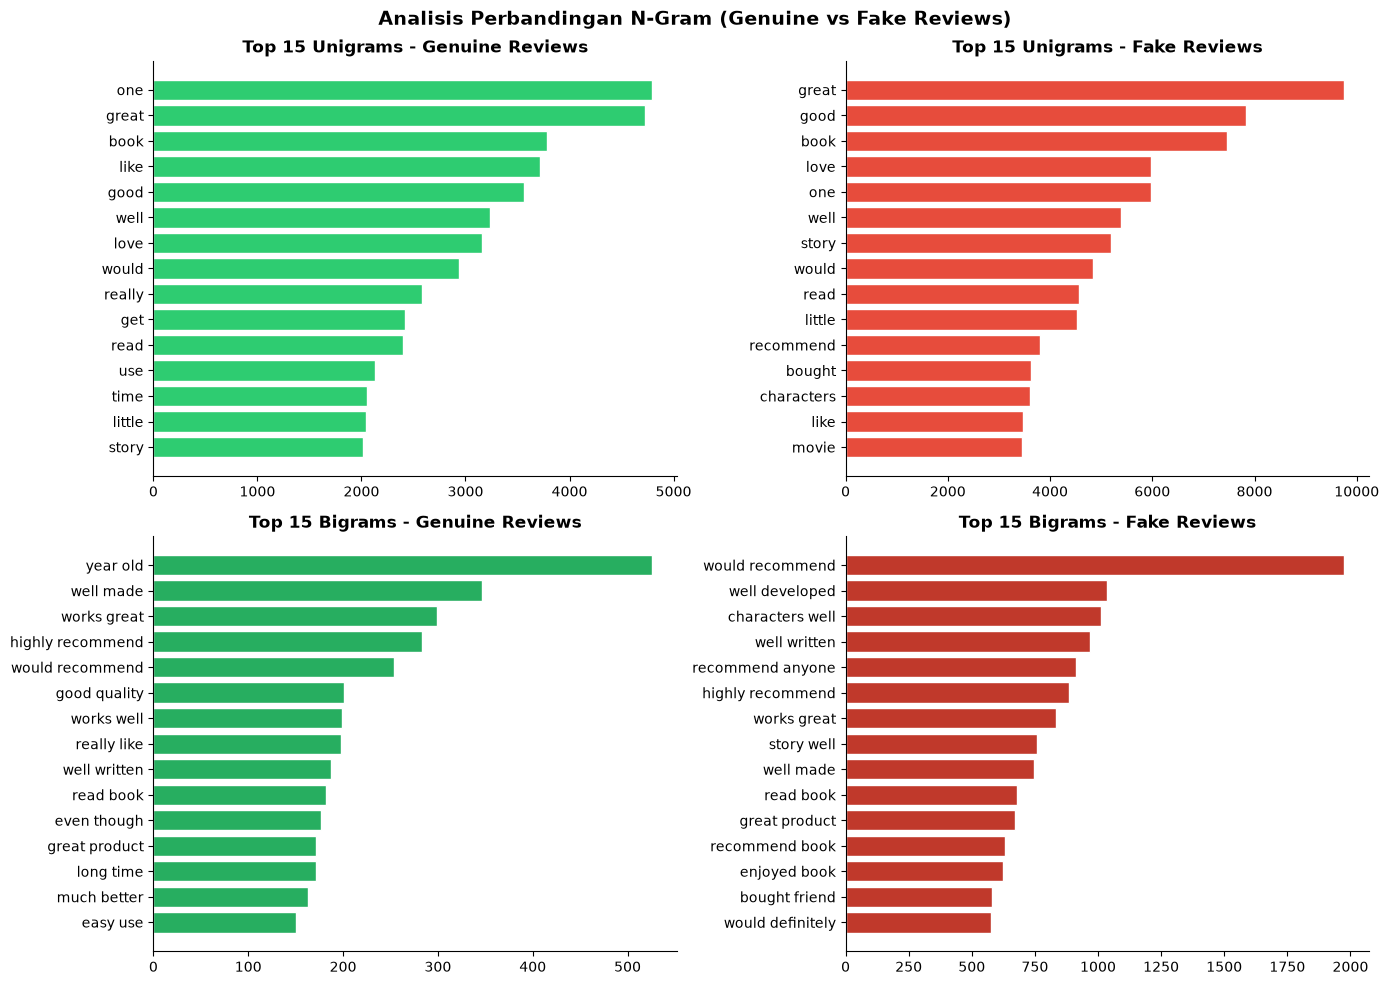

 Saved: ngram_analysis.png


In [9]:
# Deskripsi: Visualisasi perbandingan unigram dan bigram teratas pada ulasan asli vs palsu
# Visualisasi Top Unigrams & Bigrams
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Genuine Unigrams
words_gu, counts_gu = zip(*genuine_unigrams)
axes[0, 0].barh(words_gu, counts_gu, color='#2ecc71', edgecolor='white')
axes[0, 0].set_title('Top 15 Unigrams - Genuine Reviews', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].spines[['top', 'right']].set_visible(False)

# Fake Unigrams
words_fu, counts_fu = zip(*fake_unigrams)
axes[0, 1].barh(words_fu, counts_fu, color='#e74c3c', edgecolor='white')
axes[0, 1].set_title('Top 15 Unigrams - Fake Reviews', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Genuine Bigrams
words_gb, counts_gb = zip(*genuine_bigrams)
axes[1, 0].barh(words_gb, counts_gb, color='#27ae60', edgecolor='white')
axes[1, 0].set_title('Top 15 Bigrams - Genuine Reviews', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Fake Bigrams
words_fb, counts_fb = zip(*fake_bigrams)
axes[1, 1].barh(words_fb, counts_fb, color='#c0392b', edgecolor='white')
axes[1, 1].set_title('Top 15 Bigrams - Fake Reviews', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Perbandingan N-Gram (Genuine vs Fake Reviews)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ngram_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: ngram_analysis.png")


# 3. Data Preprocessing
Mengubah teks ulasan mentah menjadi bersih untuk permodelan dengan langkah: Lowercase, penghapusan angka, penghapusan tanda baca, penghapusan stopwords bahasa Inggris, dan stemming Porter Stemmer.


In [10]:
# Deskripsi: Fungsi untuk preprocessing teks (lowercase, hapus angka/tanda baca, stopword, stemming)
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Lowercase → remove digits/punctuation → stopword removal → stemming."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Contoh preprocessing
sample_raw = df['text_'].iloc[0]
sample_clean = preprocess_text(sample_raw)
print(f"Raw   : {sample_raw[:120]}")
print(f"Clean : {sample_clean[:120]}")


Raw   : Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
Clean : love well made sturdi comfort love itveri pretti


In [11]:
# Deskripsi: Fungsi untuk preprocessing teks (lowercase, hapus angka/tanda baca, stopword, stemming)
# Preprocessing seluruh dataset (±1-2 menit)
df['text_raw']   = df['text_']   # raw untuk feature engineering
df['text_clean'] = df['text_raw'].apply(preprocess_text)

print(" Preprocessing selesai!")
print(f"   Contoh clean: '{df['text_clean'].iloc[0][:80]}...'")


 Preprocessing selesai!
   Contoh clean: 'love well made sturdi comfort love itveri pretti...'


In [12]:
# Train-Test Split (stratified — menjaga proporsi label)
X_text_raw   = np.array(df['text_raw'])
X_text_clean = np.array(df['text_clean'])
y            = np.array(df['label_bin'], dtype=np.int64)

(X_train_raw, X_test_raw,
 X_train_clean, X_test_clean,
 y_train, y_test) = train_test_split(
    X_text_raw, X_text_clean, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train : {len(X_train_clean):,} samples | Fake ratio: {y_train.mean()*100:.1f}%")
print(f"Test  : {len(X_test_clean):,} samples  | Fake ratio: {y_test.mean()*100:.1f}%")


Train : 32,075 samples | Fake ratio: 49.7%
Test  : 8,019 samples  | Fake ratio: 49.7%


# 4. Baseline Experiment (TF-IDF Only)
Melakukan vektorisasi TF-IDF unigram+bigram dengan batas 10.000 fitur, melatih 4 algoritma baseline, dan menyimpan hasil performa pada test set.


In [13]:
# Deskripsi: Ekstraksi fitur leksikal ulasan menggunakan metode pembobotan TF-IDF
# 3A — TF-IDF Vectorization
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigram + bigram
    max_features=10000,
    min_df=2,
    sublinear_tf=True     # log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print(f" TF-IDF shape (train): {X_train_tfidf.shape}")
print(f"   Vocabulary size     : {len(tfidf.vocabulary_):,}")
print(f"   Sample features     : {list(tfidf.get_feature_names_out()[:10])}")


 TF-IDF shape (train): (32075, 10000)
   Vocabulary size     : 10,000
   Sample features     : ['aa', 'aa batteri', 'abandon', 'abil', 'abl', 'abl find', 'abl get', 'abl go', 'abl make', 'abl put']


In [14]:
# Deskripsi: Mendefinisikan model klasifikasi (Logistic Regression, SVM, NB, RF) dan fungsi evaluasi
# Definisi model
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, C=1.0),
    'SVM (Linear)': LinearSVC(
        max_iter=2000, class_weight='balanced',
        random_state=RANDOM_STATE, C=1.0),
    'Naive Bayes': None,   # diinisialisasi khusus
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, max_depth=20)
}

def get_nb_model():
    return MultinomialNB(alpha=0.1)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, feature_label=""):
    """Fit model, prediksi, return metrics dict + predictions."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model'    : name,
        'Feature'  : feature_label,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_te, y_pred, zero_division=0),
    }, y_pred, model

print(" Model definitions ready.")
print("   Models:", list(MODELS.keys()))


 Model definitions ready.
   Models: ['Logistic Regression', 'SVM (Linear)', 'Naive Bayes', 'Random Forest']


In [15]:
# Deskripsi: Eksperimen 1: Melatih 4 model klasifikasi baseline menggunakan fitur TF-IDF saja
print("=" * 60)
print("EXPERIMENT 1: 4 Model × TF-IDF Only")
print("=" * 60)

exp1_results = []
exp1_preds   = {}

for name, model in MODELS.items():
    mdl = get_nb_model() if name == 'Naive Bayes' else model
    res, y_pred, trained = evaluate_model(
        name, mdl, X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')
    exp1_results.append(res)
    exp1_preds[name] = (y_pred, trained)
    print(f"   {name:<25} F1={res['F1-Score']:.4f}")

df_exp1 = pd.DataFrame(exp1_results)
df_exp1.to_csv(os.path.join(RESULTS_DIR, 'exp1_tfidf_only.csv'), index=False)
print("\n Saved: exp1_tfidf_only.csv")


EXPERIMENT 1: 4 Model × TF-IDF Only
   Logistic Regression       F1=0.8732
   SVM (Linear)              F1=0.8779
   Naive Bayes               F1=0.8464
   Random Forest             F1=0.7430

 Saved: exp1_tfidf_only.csv


In [16]:
# Deskripsi: Menampilkan tabel perbandingan metrik evaluasi (Akurasi, Presisi, Recall, F1) Eksperimen 1
# Tabel hasil Experiment 1
print("\nHASIL EXPERIMENT 1:")
df_exp1[['Model','Accuracy','Precision','Recall','F1-Score']].style\
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'})\
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score'], color='#d4efdf')\
    .set_caption('Experiment 1 — Perbandingan 4 Model (TF-IDF Only)')



HASIL EXPERIMENT 1:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8753,0.8826,0.8640,0.8732
1,SVM (Linear),0.8797,0.8854,0.8705,0.8779
2,Naive Bayes,0.8519,0.8735,0.8209,0.8464
3,Random Forest,0.7772,0.8706,0.6480,0.7430


In [17]:
# Classification Report — model terbaik
f1_scores   = {r['Model']: r['F1-Score'] for r in exp1_results}
best_model  = max(f1_scores, key=f1_scores.get)
worst_model = min(f1_scores, key=f1_scores.get)

print(f"Model Terbaik  : {best_model} (F1={f1_scores[best_model]:.4f})")
print(f"Model Terburuk : {worst_model} (F1={f1_scores[worst_model]:.4f})")
print()
print(f"Classification Report — {best_model}:")
print(classification_report(y_test, exp1_preds[best_model][0],
                            target_names=['Genuine (0)', 'Fake (1)']))


Model Terbaik  : SVM (Linear) (F1=0.8779)
Model Terburuk : Random Forest (F1=0.7430)

Classification Report — SVM (Linear):
              precision    recall  f1-score   support

 Genuine (0)       0.87      0.89      0.88      4033
    Fake (1)       0.89      0.87      0.88      3986

    accuracy                           0.88      8019
   macro avg       0.88      0.88      0.88      8019
weighted avg       0.88      0.88      0.88      8019



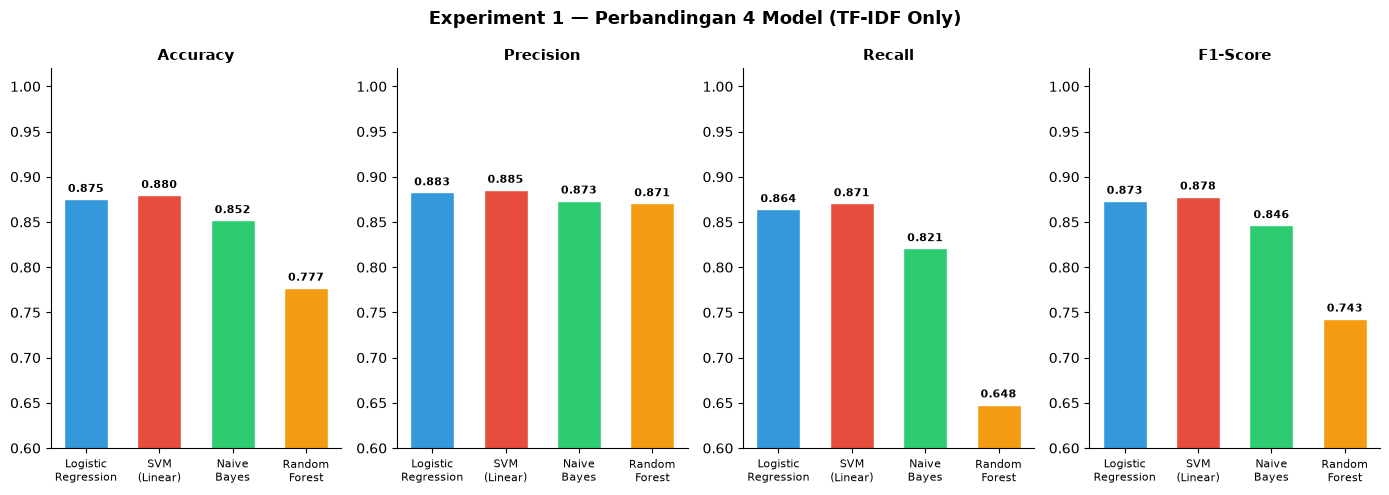

 Saved: exp1_model_comparison.png


In [18]:
# Deskripsi: Visualisasi performa perbandingan 4 model baseline (Eksperimen 1)
PALETTE = {
    'Logistic Regression': '#3498db',
    'SVM (Linear)'       : '#e74c3c',
    'Naive Bayes'        : '#2ecc71',
    'Random Forest'      : '#f39c12',
    'LightGBM'           : '#9b59b6'
}
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(MODELS.keys())

# ── Chart 1: Experiment 1 ──
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, metric in zip(axes, metrics):
    vals   = [r[metric] for r in exp1_results]
    colors = [PALETTE[r['Model']] for r in exp1_results]
    bars   = ax.bar(range(len(model_names)), vals, color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    ax.set_ylim(0.6, 1.02)
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('Experiment 1 — Perbandingan 4 Model (TF-IDF Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'exp1_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: exp1_model_comparison.png")


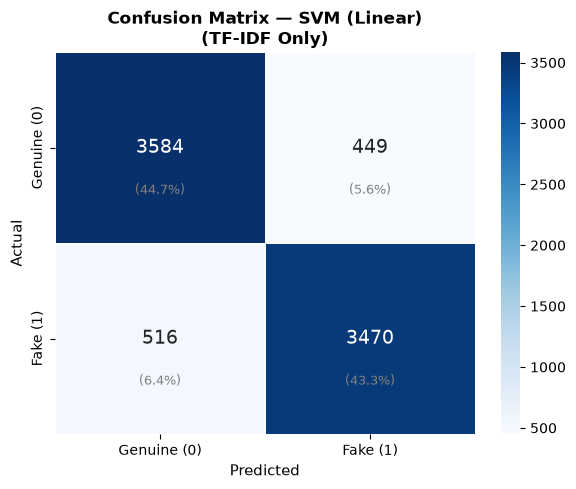

 Saved: confusion_matrix_best.png (SVM (Linear))


In [19]:
# Deskripsi: Visualisasi Confusion Matrix dari model baseline terbaik
# ── Chart 3: Confusion Matrix — Model Terbaik ──
cm  = confusion_matrix(y_test, exp1_preds[best_model][0])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine (0)', 'Fake (1)'],
            yticklabels=['Genuine (0)', 'Fake (1)'],
            ax=ax, linewidths=0.5, annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_model}\n(TF-IDF Only)', fontweight='bold')
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'({cm[i,j]/total*100:.1f}%)',
                ha='center', va='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix_best.png'), dpi=150)
plt.show()
print(f" Saved: confusion_matrix_best.png ({best_model})")


# 5. 5-Fold Cross Validation
Untuk membuktikan stabilitas dan kekuatan generalisasi dari model baseline, kami melakukan pengujian validasi silang (5-Fold Cross Validation) menggunakan data latih.


In [20]:
# Deskripsi: Menjalankan 5-Fold Cross Validation untuk menguji stabilitas performa model baseline
from sklearn.model_selection import StratifiedKFold, cross_validate

print('Menjalankan 5-Fold Cross Validation untuk semua model baseline...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_metrics = ['accuracy', 'precision', 'recall', 'f1']

cv_results_summary = []

for name, model in MODELS.items():
    mdl = get_nb_model() if name == 'Naive Bayes' else model
    scores = cross_validate(mdl, X_train_tfidf, y_train, cv=cv, scoring=cv_metrics, n_jobs=-1)
    
    cv_results_summary.append({
        'Model': name,
        'Mean Accuracy': np.mean(scores['test_accuracy']),
        'Std Accuracy': np.std(scores['test_accuracy']),
        'Mean Precision': np.mean(scores['test_precision']),
        'Std Precision': np.std(scores['test_precision']),
        'Mean Recall': np.mean(scores['test_recall']),
        'Std Recall': np.std(scores['test_recall']),
        'Mean F1-Score': np.mean(scores['test_f1']),
        'Std F1-Score': np.std(scores['test_f1'])
    })

df_cv = pd.DataFrame(cv_results_summary)
df_cv.to_csv(os.path.join(RESULTS_DIR, 'cross_validation_results.csv'), index=False)
print(' Hasil Cross-Validation berhasil disimpan!')
df_cv.round(4)


Menjalankan 5-Fold Cross Validation untuk semua model baseline...
 Hasil Cross-Validation berhasil disimpan!


,Model,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1-Score,Std F1-Score
0,Logistic Regression,0.8664,0.0031,0.8737,0.0061,0.8548,0.0061,0.8641,0.0031
1,SVM (Linear),0.8736,0.0050,0.8771,0.0079,0.8672,0.0061,0.8721,0.0049
2,Naive Bayes,0.8550,0.0032,0.8771,0.0044,0.8237,0.0085,0.8495,0.0039
3,Random Forest,0.7728,0.0030,0.8698,0.0091,0.6386,0.0119,0.7364,0.0056


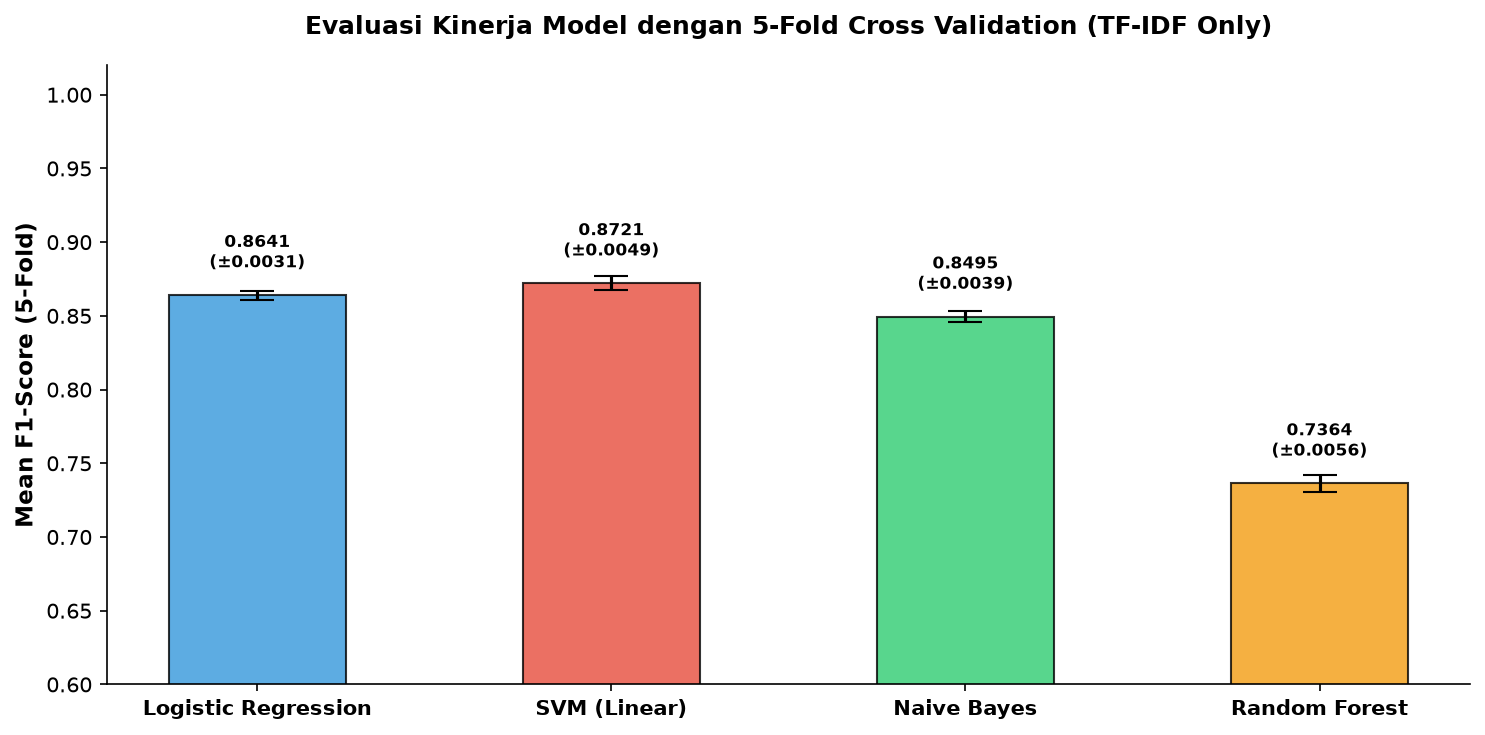

 Saved: cv_model_comparison.png


In [21]:
# Deskripsi: Visualisasi rata-rata F1-score hasil Cross Validation beserta deviasi standarnya
# Visualisasi Hasil Cross Validation dengan Error Bars
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
x_pos = np.arange(len(df_cv['Model']))
width = 0.5

ax.bar(x_pos, df_cv['Mean F1-Score'], yerr=df_cv['Std F1-Score'], align='center', alpha=0.8, 
       color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black', capsize=8, width=width)

ax.set_ylabel('Mean F1-Score (5-Fold)', fontsize=11, fontweight='bold')
ax.set_title('Evaluasi Kinerja Model dengan 5-Fold Cross Validation (TF-IDF Only)', fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_cv['Model'], fontsize=10, fontweight='bold')
ax.set_ylim(0.6, 1.02)
ax.spines[['top', 'right']].set_visible(False)

# Tambahkan label nilai
for i, row in df_cv.iterrows():
    ax.text(i, row['Mean F1-Score'] + 0.015, f"{row['Mean F1-Score']:.4f}\n(±{row['Std F1-Score']:.4f})", 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cv_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: cv_model_comparison.png')


# 6. Statistical Validation (Uji Signifikansi)
Melakukan uji statistik non-parametrik McNemar's Test untuk membandingkan tingkat kesalahan model terbaik dengan model klasifikasi lainnya pada test set.

> **Catatan**: Untuk membandingkan model baseline TF-IDF Only dengan model kombinasi TF-IDF + Feature Engineering, ulasan akan diekstrak fiturnya dan model kombinasi (Experiment 2) dilatih secara dinamis di dalam sel ini guna mencegah terjadinya *NameError*.


In [22]:
# Deskripsi: Eksperimen 2: Melatih model gabungan (TF-IDF + FE) dan melakukan validasi signifikansi McNemar
# ── PREPARASI FITUR & EXPERIMENT 2 UNTUK VALIDASI STATISTIK ──
analyzer = SentimentIntensityAnalyzer()

def extract_features_temp(texts):
    records = []
    for text in texts:
        words      = text.split()
        word_count = len(words) if words else 1
        text_length      = len(text)
        exclamation_count = text.count('!')
        upper_words      = [w for w in words if w.isupper() and len(w) > 1]
        uppercase_ratio  = len(upper_words) / word_count
        sentiment_score  = analyzer.polarity_scores(text)['compound']
        unique_words     = set(w.lower() for w in words)
        lexical_diversity = len(unique_words) / word_count
        records.append([text_length, exclamation_count, uppercase_ratio, sentiment_score, lexical_diversity])
    return pd.DataFrame(records, columns=['text_length', 'exclamation_count', 'uppercase_ratio', 'sentiment_score', 'lexical_diversity'])

print('Mengekstrak fitur buatan secara paralel untuk validasi statistik...')
FE_train_df = extract_features_temp(X_train_raw)
FE_test_df  = extract_features_temp(X_test_raw)

scaler = StandardScaler()
FE_train_scaled = scaler.fit_transform(FE_train_df)
FE_test_scaled  = scaler.transform(FE_test_df)

X_train_combined = hstack([X_train_tfidf, csr_matrix(FE_train_scaled)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(FE_test_scaled)])

print('Melatih model kombinasi (TF-IDF + FE)...')
exp2_results = []
exp2_preds = {}

for name, model in MODELS.items():
    res_a = next(r for r in exp1_results if r['Model'] == name)
    exp2_results.append({**res_a, 'Feature': 'TF-IDF Only'})

    if name == 'Naive Bayes':
        FE_abs    = np.abs(FE_train_scaled)
        FE_abs_te = np.abs(FE_test_scaled)
        X_tr_c = hstack([X_train_tfidf, csr_matrix(FE_abs)])
        X_te_c = hstack([X_test_tfidf,  csr_matrix(FE_abs_te)])
        mdl = get_nb_model()
    else:
        X_tr_c = X_train_combined
        X_te_c = X_test_combined
        mdl = MODELS[name].__class__(**MODELS[name].get_params())

    res_b, y_pred_b, trained_b = evaluate_model(name, mdl, X_tr_c, X_te_c, y_train, y_test, 'TF-IDF + FE')
    exp2_results.append(res_b)
    exp2_preds[name] = (y_pred_b, trained_b)

df_exp2 = pd.DataFrame(exp2_results)
df_exp2.to_csv(os.path.join(RESULTS_DIR, 'exp2_feature_engineering.csv'), index=False)
print(' Seluruh model kombinasi selesai dilatih! Variable exp2_preds telah didefinisikan.')

# ── UJI SIGNIFIKANSI MCNEMAR ───────────────────────────────
def run_mcnemar(y_true, pred_a, pred_b, label_a, label_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum( correct_a & ~correct_b)
    c = np.sum(~correct_a &  correct_b)
    table  = [[np.sum(correct_a & correct_b), b],
              [c, np.sum(~correct_a & ~correct_b)]]
    result = mcnemar(table, exact=True)
    sig    = " SIGNIFIKAN" if result.pvalue < 0.05 else " Tidak Signifikan"
    print(f"  {label_a} vs {label_b}")
    print(f"  b={b}, c={c}, p-value={result.pvalue:.6f}  → {sig}")
    print()
    return result.pvalue

print("=" * 60)
print("MCNEMAR'S TEST")
print("=" * 60)

print("[Comparison 1] Model terbaik vs terburuk (Exp1 TF-IDF)")
p1 = run_mcnemar(y_test,
                 exp1_preds[best_model][0], exp1_preds[worst_model][0],
                 best_model, worst_model)

print(f"[Comparison 2] {best_model}: TF-IDF Only vs TF-IDF + FE")
p2 = run_mcnemar(y_test,
                 exp1_preds[best_model][0], exp2_preds[best_model][0],
                 'TF-IDF Only', 'TF-IDF + FE')

pd.DataFrame([
    {'Comparison': f'{best_model} vs {worst_model}', 'p_value': p1, 'Significant': p1 < 0.05},
    {'Comparison': f'{best_model}: TF-IDF vs TF-IDF+FE', 'p_value': p2, 'Significant': p2 < 0.05},
]).to_csv(os.path.join(RESULTS_DIR, 'mcnemar_test.csv'), index=False)
print(" Saved: mcnemar_test.csv")


Mengekstrak fitur buatan secara paralel untuk validasi statistik...
Melatih model kombinasi (TF-IDF + FE)...
 Seluruh model kombinasi selesai dilatih! Variable exp2_preds telah didefinisikan.
MCNEMAR'S TEST
[Comparison 1] Model terbaik vs terburuk (Exp1 TF-IDF)
  SVM (Linear) vs Random Forest
  b=1234, c=412, p-value=0.000000  →  SIGNIFIKAN

[Comparison 2] SVM (Linear): TF-IDF Only vs TF-IDF + FE
  TF-IDF Only vs TF-IDF + FE
  b=149, c=245, p-value=0.000002  →  SIGNIFIKAN

 Saved: mcnemar_test.csv


# 7. Feature Engineering
Mengekstrak 5 fitur linguistik numerik dari ulasan untuk menangkap perbedaan struktural gaya bahasa (*stylometric*) dan sentimen emosional.


In [23]:
# Deskripsi: Fungsi ekstraksi 5 fitur linguistik (panjang teks, tanda seru, rasio kapital, sentimen, lexical diversity)
# 3B — Feature Engineering
analyzer = SentimentIntensityAnalyzer()

PROMO_WORDS = {
    'discount', 'promo', 'sponsored', 'affiliate', 'buy', 'deal',
    'recommend', 'price', 'coupon', 'sale', 'offer', 'free', 'click',
    'shipping', 'code', 'purchase', 'review', 'product', 'promote'
}

def extract_features(texts):
    """Ekstrak 5 fitur linguistik dari raw text (sebelum preprocessing)."""
    records = []
    for text in texts:
        words      = text.split()
        word_count = len(words) if words else 1

        text_length      = len(text)
        exclamation_count = text.count('!')
        upper_words      = [w for w in words if w.isupper() and len(w) > 1]
        uppercase_ratio  = len(upper_words) / word_count
        sentiment_score  = analyzer.polarity_scores(text)['compound']
        unique_words     = set(w.lower() for w in words)
        lexical_diversity = len(unique_words) / word_count

        records.append([text_length, exclamation_count, uppercase_ratio,
                        sentiment_score, lexical_diversity])

    return pd.DataFrame(records, columns=[
        'text_length', 'exclamation_count', 'uppercase_ratio',
        'sentiment_score', 'lexical_diversity'
    ])

print("Mengekstrak fitur train... (±1-2 menit)")
FE_train_df = extract_features(X_train_raw)
print("Mengekstrak fitur test...")
FE_test_df  = extract_features(X_test_raw)
print(" Feature Engineering selesai!")
FE_train_df.describe().round(3)


Mengekstrak fitur train... (±1-2 menit)
Mengekstrak fitur test...
 Feature Engineering selesai!


,text_length,exclamation_count,uppercase_ratio,sentiment_score,lexical_diversity
count,32075.000,32075.000,32075.000,32075.000,32075.000
mean,259.602,0.328,0.010,0.566,0.820
std,258.575,1.246,0.066,0.467,0.145
min,1.000,0.000,0.000,-1.000,0.029
25%,92.000,0.000,0.000,0.361,0.735
50%,164.000,0.000,0.000,0.764,0.842
75%,325.000,0.000,0.000,0.918,0.933
max,2006.000,133.000,1.000,1.000,1.000


In [24]:
# Deskripsi: Melakukan standarisasi (scaling) fitur linguistik dan menggabungkannya dengan fitur TF-IDF
# Scale + Gabungkan TF-IDF & Feature Engineering
scaler           = StandardScaler()
FE_train_scaled  = scaler.fit_transform(FE_train_df)
FE_test_scaled   = scaler.transform(FE_test_df)

X_train_combined = hstack([X_train_tfidf, csr_matrix(FE_train_scaled)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(FE_test_scaled)])

print(f"TF-IDF Only shape  : {X_train_tfidf.shape}")
print(f"TF-IDF + FE shape  : {X_train_combined.shape}")
print(f"(+{X_train_combined.shape[1] - X_train_tfidf.shape[1]} engineered features)")


TF-IDF Only shape  : (32075, 10000)
TF-IDF + FE shape  : (32075, 10005)
(+5 engineered features)


In [25]:
# Deskripsi: Menampilkan rata-rata nilai fitur linguistik hasil rekayasa per kelas target
# Perbandingan Statistik Deskriptif Fitur Linguistik berdasarkan Kelas
print('=== RATA-RATA NILAI FITUR LINGUISTIK PER KELAS ===')
FE_train_df['label'] = y_train
summary_stats = FE_train_df.groupby('label').mean().T
summary_stats.columns = ['Genuine (OR = 0)', 'Fake (CG = 1)']
FE_train_df.drop(columns=['label'], inplace=True)
summary_stats.round(4)


=== RATA-RATA NILAI FITUR LINGUISTIK PER KELAS ===


,Genuine (OR = 0),Fake (CG = 1)
text_length,266.9113,252.2067
exclamation_count,0.4030,0.2516
uppercase_ratio,0.0117,0.0082
sentiment_score,0.5326,0.5998
lexical_diversity,0.8560,0.7826


# 8. Feature Ablation Study
Melakukan studi pemotongan (*ablation study*) menggunakan model terbaik untuk melihat kontribusi parsial dari masing-masing fitur linguistik yang digabungkan dengan representasi TF-IDF.


In [26]:
# Deskripsi: Melakukan standarisasi (scaling) fitur linguistik dan menggabungkannya dengan fitur TF-IDF
print(f'Menjalankan Feature Ablation Study menggunakan model: {best_model}')
ablation_results = []

feature_sets = {
    'TF-IDF Only': (X_train_tfidf, X_test_tfidf),
    'TF-IDF + Sentiment': (
        hstack([X_train_tfidf, csr_matrix(FE_train_scaled[:, [3]])]), # sentiment_score index 3
        hstack([X_test_tfidf, csr_matrix(FE_test_scaled[:, [3]])])
    ),
    'TF-IDF + Review Length': (
        hstack([X_train_tfidf, csr_matrix(FE_train_scaled[:, [0]])]), # text_length index 0
        hstack([X_test_tfidf, csr_matrix(FE_test_scaled[:, [0]])])
    ),
    'TF-IDF + Uppercase Ratio': (
        hstack([X_train_tfidf, csr_matrix(FE_train_scaled[:, [2]])]), # uppercase_ratio index 2
        hstack([X_test_tfidf, csr_matrix(FE_test_scaled[:, [2]])])
    ),
    'TF-IDF + Exclamation Count': (
        hstack([X_train_tfidf, csr_matrix(FE_train_scaled[:, [1]])]), # exclamation_count index 1
        hstack([X_test_tfidf, csr_matrix(FE_test_scaled[:, [1]])])
    ),
    'TF-IDF + Lexical Diversity': (
        hstack([X_train_tfidf, csr_matrix(FE_train_scaled[:, [4]])]), # lexical_diversity index 4
        hstack([X_test_tfidf, csr_matrix(FE_test_scaled[:, [4]])])
    ),
    'TF-IDF + All Features (Combined)': (X_train_combined, X_test_combined)
}

for set_name, (X_tr, X_te) in feature_sets.items():
    if best_model == 'Naive Bayes':
        if '+' in set_name or 'Combined' in set_name:
            tfidf_cols = X_train_tfidf.shape[1]
            non_tfidf_tr = np.abs(X_tr.tocsc()[:, tfidf_cols:].toarray())
            non_tfidf_te = np.abs(X_te.tocsc()[:, tfidf_cols:].toarray())
            X_tr_nb = hstack([X_train_tfidf, csr_matrix(non_tfidf_tr)])
            X_te_nb = hstack([X_test_tfidf, csr_matrix(non_tfidf_te)])
            mdl = get_nb_model()
            res, _, _ = evaluate_model(best_model, mdl, X_tr_nb, X_te_nb, y_train, y_test, set_name)
        else:
            mdl = get_nb_model()
            res, _, _ = evaluate_model(best_model, mdl, X_tr, X_te, y_train, y_test, set_name)
    else:
        base_model_obj = MODELS[best_model]
        mdl = base_model_obj.__class__(**base_model_obj.get_params())
        res, _, _ = evaluate_model(best_model, mdl, X_tr, X_te, y_train, y_test, set_name)
        
    ablation_results.append({
        'Feature Configuration': set_name,
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score']
    })

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv(os.path.join(RESULTS_DIR, 'feature_ablation_study.csv'), index=False)
print(' Hasil Studi Ablasi disimpan!')
df_ablation.round(4)


Menjalankan Feature Ablation Study menggunakan model: SVM (Linear)
 Hasil Studi Ablasi disimpan!


,Feature Configuration,Accuracy,Precision,Recall,F1-Score
0,TF-IDF Only,0.8797,0.8854,0.8705,0.8779
1,TF-IDF + Sentiment,0.8800,0.8859,0.8708,0.8783
2,TF-IDF + Review Length,0.8854,0.8933,0.8738,0.8834
3,TF-IDF + Uppercase Ratio,0.8800,0.8857,0.8710,0.8783
4,TF-IDF + Exclamation Count,0.8794,0.8854,0.8700,0.8776
5,TF-IDF + Lexical Diversity,0.8925,0.8979,0.8843,0.8911
6,TF-IDF + All Features (Combined),0.8916,0.8965,0.8841,0.8902


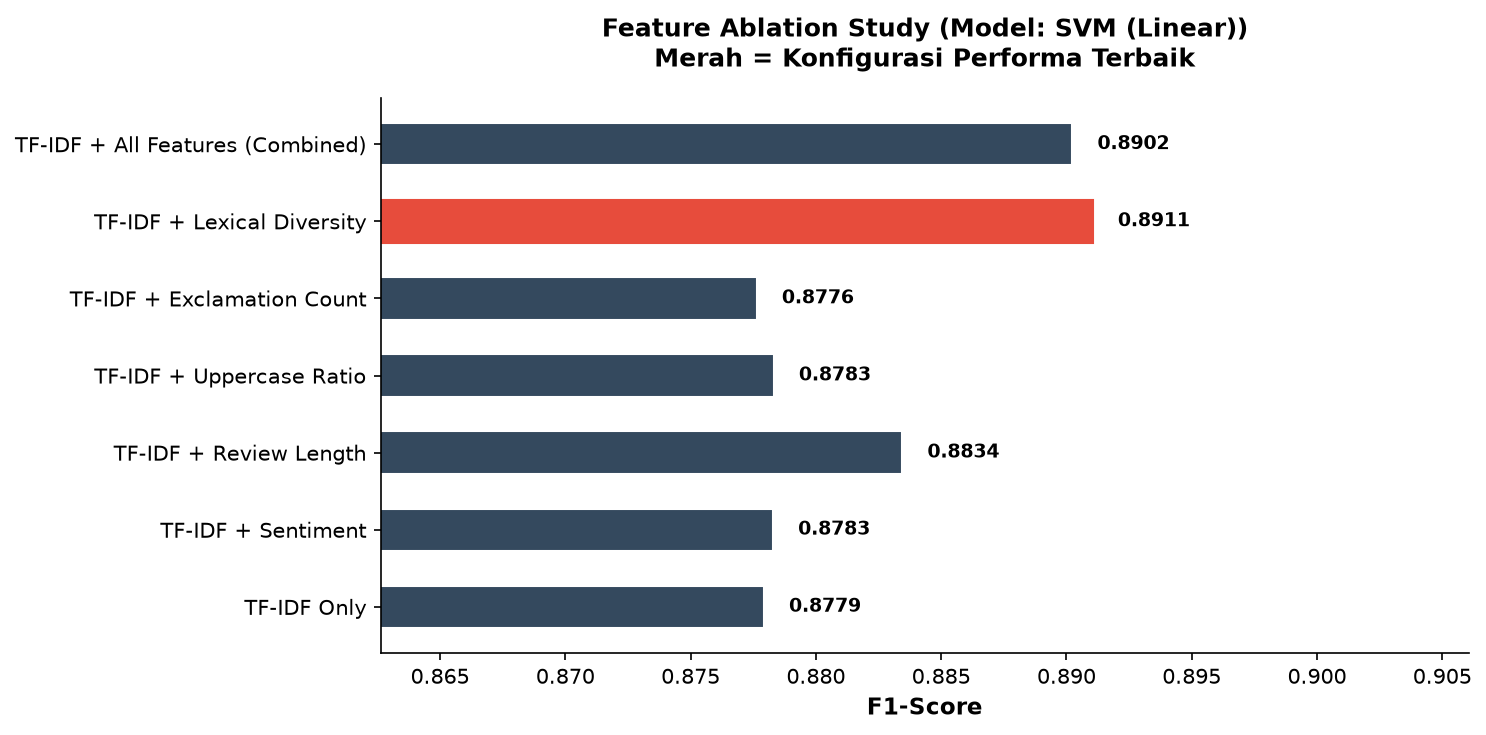

 Saved: feature_ablation_study.png


In [27]:
# Deskripsi: Menampilkan model terbaik dan terburuk beserta classification report lengkapnya
# Visualisasi Pengaruh Ablasi Fitur terhadap F1-Score
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
x_labels = df_ablation['Feature Configuration'].values
f1_scores = df_ablation['F1-Score'].values

bars = ax.barh(x_labels, f1_scores, color='#34495e', edgecolor='white', height=0.55)

best_idx = np.argmax(f1_scores)
bars[best_idx].set_color('#e74c3c')

ax.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax.set_title(f'Feature Ablation Study (Model: {best_model})\nMerah = Konfigurasi Performa Terbaik', fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(min(f1_scores) - 0.015, max(f1_scores) + 0.015)
ax.spines[['top', 'right']].set_visible(False)

# Tambahkan label nilai
for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: feature_ablation_study.png')


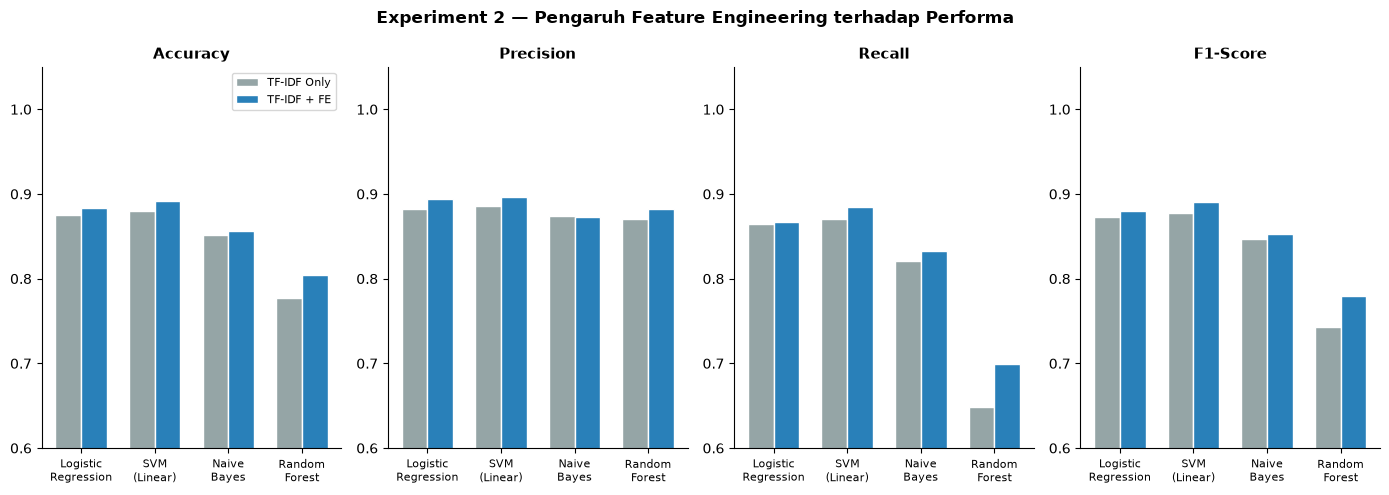

 Saved: exp2_feature_engineering.png


In [28]:
# Deskripsi: Visualisasi perbandingan metrik evaluasi Eksperimen 1 (TF-IDF) vs Eksperimen 2 (TF-IDF + FE)
# ── Chart 2: Experiment 2 ──
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
x, w = np.arange(len(model_names)), 0.35

for ax, metric in zip(axes, metrics):
    vals_a = [r[metric] for r in exp2_results if r['Feature']=='TF-IDF Only']
    vals_b = [r[metric] for r in exp2_results if r['Feature']=='TF-IDF + FE']
    ax.bar(x-w/2, vals_a, w, label='TF-IDF Only', color='#95a5a6', edgecolor='white')
    ax.bar(x+w/2, vals_b, w, label='TF-IDF + FE', color='#2980b9', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in model_names], fontsize=8)
    ax.set_ylim(0.6, 1.05)
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Experiment 2 — Pengaruh Feature Engineering terhadap Performa',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'exp2_feature_engineering.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: exp2_feature_engineering.png")


# 9. Feature Correlation
Menganalisis korelasi Point-Biserial untuk melihat keterkaitan linier statistik antara masing-masing engineered feature dengan label kelas ulasan.


In [29]:
# Deskripsi: Analisis korelasi Point-Biserial antara fitur linguistik hasil rekayasa dengan label ulasan
FE_train_df['label'] = y_train

print(f"{'Feature':<25} {'Correlation':>12} {'p-value':>14} {'Signifikan':>12}")
print("-" * 65)

fe_corr_results = {}
for col in ['text_length', 'exclamation_count', 'uppercase_ratio',
            'sentiment_score', 'lexical_diversity']:
    corr, pval = pointbiserialr(FE_train_df[col], FE_train_df['label'])
    sig = " Ya" if pval < 0.05 else " Tidak"
    fe_corr_results[col] = {'correlation': corr, 'p_value': pval, 'significant': sig}
    print(f"{col:<25} {corr:>12.4f} {pval:>14.4e} {sig:>12}")

# Simpan
pd.DataFrame(fe_corr_results).T.to_csv(
    os.path.join(RESULTS_DIR, 'feature_correlation.csv'))
print("\n Saved: feature_correlation.csv")

FE_train_df.drop(columns=['label'], inplace=True)


Feature                    Correlation        p-value   Signifikan
-----------------------------------------------------------------
text_length                    -0.0284     3.5212e-07           Ya
exclamation_count              -0.0607     1.3663e-27           Ya
uppercase_ratio                -0.0263     2.4516e-06           Ya
sentiment_score                 0.0719     4.9051e-38           Ya
lexical_diversity              -0.2529     0.0000e+00           Ya

 Saved: feature_correlation.csv


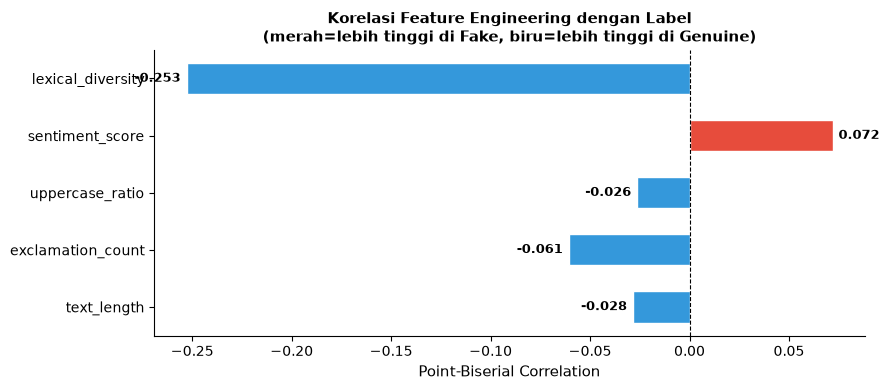

 Saved: feature_correlation.png


In [30]:
# Deskripsi: Visualisasi nilai korelasi Point-Biserial fitur linguistik hasil rekayasa
# Visualisasi korelasi
fig, ax = plt.subplots(figsize=(9, 4))
corr_vals = [fe_corr_results[f]['correlation'] for f in fe_corr_results]
colors    = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals]
bars      = ax.barh(list(fe_corr_results.keys()), corr_vals,
                    color=colors, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Point-Biserial Correlation", fontsize=11)
ax.set_title("Korelasi Feature Engineering dengan Label\n(merah=lebih tinggi di Fake, biru=lebih tinggi di Genuine)",
             fontsize=11, fontweight='bold')
for bar, val in zip(bars, corr_vals):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_correlation.png'), dpi=150)
plt.show()
print(" Saved: feature_correlation.png")


# 10. Feature Importance
Menganalisis bobot tingkat pentingnya fitur kosakata (TF-IDF) dibandingkan fitur stilometrik-sentimen menggunakan Random Forest Classifier.


In [31]:
# Deskripsi: Analisis tingkat pentingnya fitur (Feature Importance) menggunakan algoritma Random Forest
rf_model    = exp2_preds['Random Forest'][1]
fe_names    = FE_train_df.columns.tolist()
tfidf_names = tfidf.get_feature_names_out().tolist()
all_names   = tfidf_names + fe_names

importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': all_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

top_tfidf = fi_df[fi_df['feature'].isin(tfidf_names)].head(15)
top_fe    = fi_df[fi_df['feature'].isin(fe_names)]

print("Top 10 TF-IDF Features:")
print(top_tfidf.head(10).to_string(index=False))
print("\nEngineered Features Importance:")
print(top_fe.to_string(index=False))

fi_df.to_csv(os.path.join(RESULTS_DIR, 'feature_importance_rf.csv'), index=False)
print("\n Saved: feature_importance_rf.csv")


Top 10 TF-IDF Features:
        feature  importance
           even    0.015599
           much    0.014834
          littl    0.012576
         bought    0.011751
      recommend    0.011748
   charact well    0.011212
   well develop    0.010122
          small    0.009571
would recommend    0.009395
           also    0.008831

Engineered Features Importance:
          feature  importance
lexical_diversity    0.055485
      text_length    0.030869
  sentiment_score    0.023893
  uppercase_ratio    0.012713
exclamation_count    0.009119

 Saved: feature_importance_rf.csv


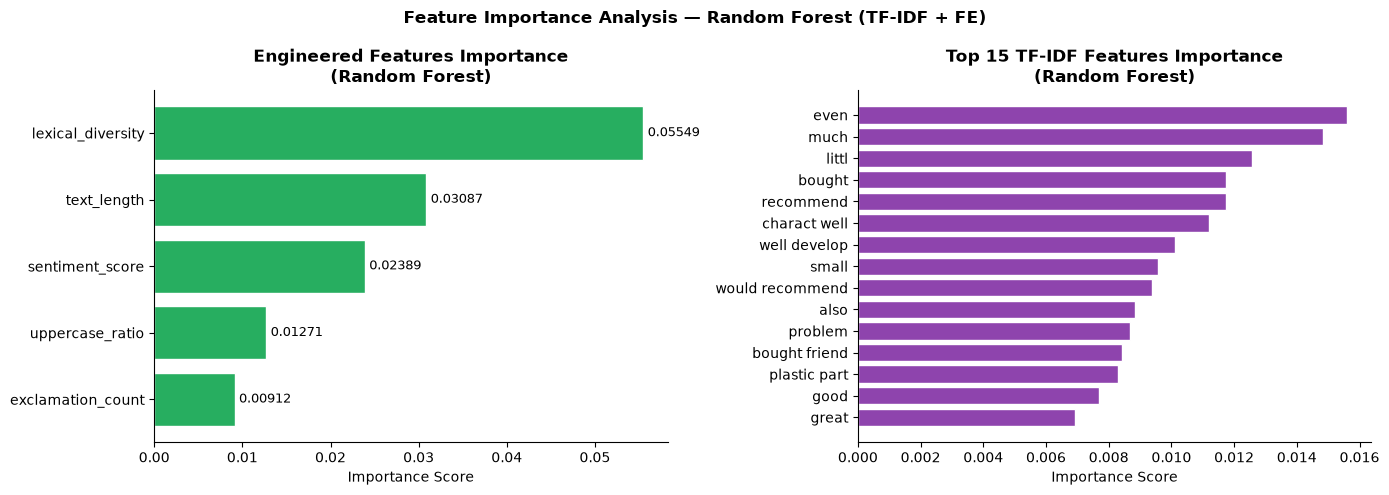

 Saved: feature_importance.png


In [32]:
# Deskripsi: Visualisasi peringkat tingkat pentingnya fitur TF-IDF vs fitur linguistik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engineered features
top_fe_s = top_fe.sort_values('importance', ascending=True)
axes[0].barh(top_fe_s['feature'], top_fe_s['importance'],
             color='#27ae60', edgecolor='white')
for i, v in enumerate(top_fe_s['importance']):
    axes[0].text(v + 0.0005, i, f'{v:.5f}', va='center', fontsize=9)
axes[0].set_title('Engineered Features Importance\n(Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].spines[['top','right']].set_visible(False)

# Top 15 TF-IDF features
top_tfidf_s = top_tfidf.sort_values('importance', ascending=True)
axes[1].barh(top_tfidf_s['feature'], top_tfidf_s['importance'],
             color='#8e44ad', edgecolor='white')
axes[1].set_title('Top 15 TF-IDF Features Importance\n(Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Feature Importance Analysis — Random Forest (TF-IDF + FE)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: feature_importance.png")


# 11. Error Analysis (Analisis Kesalahan Kualitatif & Kuantitatif)
Menganalisis data uji yang gagal dideteksi secara tepat oleh model terbaik untuk membandingkan karakteristik ulasan *False Positives* (FP) dan *False Negatives* (FN).


In [33]:
# Deskripsi: Pengelompokan data uji berdasarkan TP, TN, FP, FN untuk analisis kesalahan kuantitatif
y_pred_best = exp1_preds[best_model][0]

# Dapatkan indeks TP, TN, FP, FN
tp_idx = np.where((y_test == 1) & (y_pred_best == 1))[0]
tn_idx = np.where((y_test == 0) & (y_pred_best == 0))[0]
fp_idx = np.where((y_test == 0) & (y_pred_best == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_best == 0))[0]

print(f'Pembagian Kelompok: TP={len(tp_idx)} | TN={len(tn_idx)} | FP={len(fp_idx)} | FN={len(fn_idx)}')

# Hitung metrik rata-rata per kelompok
error_groups = {
    'True Positive (TP)': tp_idx,
    'True Negative (TN)': tn_idx,
    'False Positive (FP)': fp_idx,
    'False Negative (FN)': fn_idx
}

error_summary = []
for grp_name, indices in error_groups.items():
    if len(indices) > 0:
        subset_fe = FE_test_df.iloc[indices]
        error_summary.append({
            'Kelompok': grp_name,
            'Total Ulasan': len(indices),
            'Rata-rata Panjang Karakter': subset_fe['text_length'].mean(),
            'Rata-rata Tanda Seru': subset_fe['exclamation_count'].mean(),
            'Rata-rata Rasio Kapital': subset_fe['uppercase_ratio'].mean(),
            'Rata-rata Sentimen VADER': subset_fe['sentiment_score'].mean(),
            'Rata-rata Diversitas Leksikal': subset_fe['lexical_diversity'].mean()
        })

df_errors = pd.DataFrame(error_summary)
df_errors.to_csv(os.path.join(RESULTS_DIR, 'error_analysis_comparison.csv'), index=False)
print(' Hasil analisis kesalahan kuantitatif disimpan!')
df_errors.round(3)


Pembagian Kelompok: TP=3470 | TN=3584 | FP=449 | FN=516
 Hasil analisis kesalahan kuantitatif disimpan!


,Kelompok,Total Ulasan,Rata-rata Panjang Karakter,Rata-rata Tanda Seru,Rata-rata Rasio Kapital,Rata-rata Sentimen VADER,Rata-rata Diversitas Leksikal
0,True Positive (TP),3470,265.663,0.242,0.007,0.626,0.770
1,True Negative (TN),3584,283.170,0.421,0.011,0.532,0.849
2,False Positive (FP),449,120.581,0.265,0.019,0.511,0.912
3,False Negative (FN),516,167.591,0.180,0.018,0.463,0.843


In [34]:
# Deskripsi: Menampilkan sampel ulasan pada kasus klasifikasi salah (False Positives dan False Negatives)
# Ekstrak prediksi dari model terbaik
best_model_name = best_model
y_pred_best = exp1_preds[best_model_name][0]

# Cari False Positives (Actual = 0, Predicted = 1)
fp_indices = np.where((y_test == 0) & (y_pred_best == 1))[0]
# Cari False Negatives (Actual = 1, Predicted = 0)
fn_indices = np.where((y_test == 1) & (y_pred_best == 0))[0]

print(f"Total False Positives (FP): {len(fp_indices):,}")
print(f"Total False Negatives (FN): {len(fn_indices):,}")

# Ambil contoh untuk analisis kualitatif
num_samples = min(3, len(fp_indices), len(fn_indices))

print("\n" + "="*80)
print(" ANALISIS FALSE POSITIVES (Review Asli tapi diprediksi Palsu)")
print("="*80)
for i in range(num_samples):
    idx = fp_indices[i]
    print(f"Sampel FP #{i+1}:")
    print(f"  Teks Review : {X_test_raw[idx][:250]}...")
    print(f"  Word Count  : {len(X_test_raw[idx].split())}")
    print(f"  Score VADER : {FE_test_df.iloc[idx]['sentiment_score']:.4f}")
    print(f"  Lex Diversity: {FE_test_df.iloc[idx]['lexical_diversity']:.4f}")
    print("-" * 50)

print("\n" + "="*80)
print(" ANALISIS FALSE NEGATIVES (Review Palsu tapi diprediksi Asli)")
print("="*80)
for i in range(num_samples):
    idx = fn_indices[i]
    print(f"Sampel FN #{i+1}:")
    print(f"  Teks Review : {X_test_raw[idx][:250]}...")
    print(f"  Word Count  : {len(X_test_raw[idx].split())}")
    print(f"  Score VADER : {FE_test_df.iloc[idx]['sentiment_score']:.4f}")
    print(f"  Lex Diversity: {FE_test_df.iloc[idx]['lexical_diversity']:.4f}")
    print("-" * 50)


Total False Positives (FP): 449
Total False Negatives (FN): 516

 ANALISIS FALSE POSITIVES (Review Asli tapi diprediksi Palsu)
Sampel FP #1:
  Teks Review : This is as good as all of her other books, lots of humor, suspense, shenanegins...great book, can't wait for the next one....
  Word Count  : 22
  Score VADER : 0.6124
  Lex Diversity: 0.9091
--------------------------------------------------
Sampel FP #2:
  Teks Review : avatar has nothing on this movie this is the best movie in american history. the era it was made in considering that everthing looks very real....
  Word Count  : 26
  Score VADER : 0.6369
  Lex Diversity: 0.8462
--------------------------------------------------
Sampel FP #3:
  Teks Review : This is an interesting product...
  Word Count  : 5
  Score VADER : 0.4019
  Lex Diversity: 1.0000
--------------------------------------------------

 ANALISIS FALSE NEGATIVES (Review Palsu tapi diprediksi Asli)
Sampel FN #1:
  Teks Review : Like many others posting reviews,

# 12. Linguistic Analysis
Melakukan analisis pola klasifikasi deskriptif berbasis aturan (*rule-based*) dan mengidentifikasi perbedaan frekuensi kosakata promosi yang dominan muncul.


In [35]:
# Deskripsi: Fungsi ekstraksi 5 fitur linguistik (panjang teks, tanda seru, rasio kapital, sentimen, lexical diversity)
PROMO_WORDS = {
    'discount','promo','sponsored','affiliate','buy','deal','recommend',
    'price','coupon','sale','offer','free','click','shipping','code',
    'purchase','review','product','promote'
}

def analyze_pattern(text, sentiment_score, lexical_diversity, word_count):
    """Rule-based pattern analysis — multi-label deskriptif."""
    patterns = []
    words    = text.lower().split()

    if abs(sentiment_score) > 0.75 and word_count > 20:
        patterns.append('Deceptive')
    if lexical_diversity < 0.40:
        patterns.append('Bot-Generated')
    if word_count < 15:
        patterns.append('Spam')
    if sum(1 for w in words if w in PROMO_WORDS) >= 2:
        patterns.append('Paid/Promotional')

    return patterns if patterns else ['Unclassified']

# Terapkan ke prediksi Fake saja
y_pred_test  = exp1_preds[best_model][1].predict(X_test_tfidf)
fake_indices = np.where(y_pred_test == 1)[0]
fake_texts   = X_test_raw[fake_indices]
fake_fe      = FE_test_df.iloc[fake_indices].reset_index(drop=True)

pattern_counts  = {'Deceptive':0,'Bot-Generated':0,'Spam':0,'Paid/Promotional':0,'Unclassified':0}
pattern_records = []

for txt, (_, fe_row) in zip(fake_texts, fake_fe.iterrows()):
    patterns = analyze_pattern(txt, fe_row['sentiment_score'],
                               fe_row['lexical_diversity'], len(txt.split()))
    for p in patterns:
        pattern_counts[p] += 1
    pattern_records.append({'text_preview': txt[:80], 'patterns': ', '.join(patterns)})

total_fake = len(fake_texts)
print(f"Total prediksi Fake  : {total_fake:,}")
print(f"\n{'Pattern':<20} {'Count':>8} {'%':>8}")
print("-" * 40)
for k, v in pattern_counts.items():
    bar = '▓' * int(v / total_fake * 30)
    print(f"{k:<20} {v:>8,} {v/total_fake*100:>7.1f}%  {bar}")

pd.DataFrame(pattern_records).to_csv(
    os.path.join(RESULTS_DIR, 'rule_based_patterns.csv'), index=False)
print("\n Saved: rule_based_patterns.csv")


Total prediksi Fake  : 3,919

Pattern                 Count        %
----------------------------------------
Deceptive               1,768    45.1%  ▓▓▓▓▓▓▓▓▓▓▓▓▓
Bot-Generated              64     1.6%  
Spam                      496    12.7%  ▓▓▓
Paid/Promotional          300     7.7%  ▓▓
Unclassified            1,616    41.2%  ▓▓▓▓▓▓▓▓▓▓▓▓

 Saved: rule_based_patterns.csv


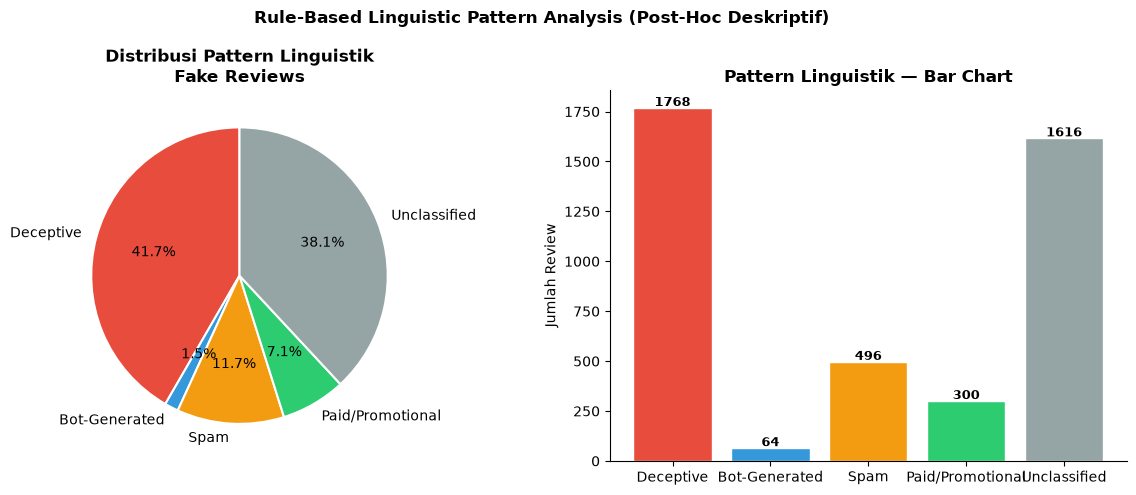

 Saved: rulebased_patterns.png


In [36]:
# ── Chart 4: Rule-Based Pattern Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pnz    = {k: v for k, v in pattern_counts.items() if v > 0}
colors = ['#e74c3c','#3498db','#f39c12','#2ecc71','#95a5a6']

axes[0].pie(pnz.values(), labels=pnz.keys(), autopct='%1.1f%%',
            colors=colors[:len(pnz)], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Distribusi Pattern Linguistik\nFake Reviews', fontweight='bold')

bars = axes[1].bar(pnz.keys(), pnz.values(),
                   color=colors[:len(pnz)], edgecolor='white')
axes[1].set_ylabel('Jumlah Review')
axes[1].set_title('Pattern Linguistik — Bar Chart', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, pnz.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 str(v), ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Rule-Based Linguistic Pattern Analysis (Post-Hoc Deskriptif)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'rulebased_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: rulebased_patterns.png")


In [37]:
# Deskripsi: Menampilkan perbandingan 10 unigram dan bigram dominan pada ulasan asli vs palsu
# ── PERBANDINGAN KOSAKATA STRUKTURAL ──────────────────────
print('=== TOP 10 UNIGRAMS PADA GENUINE REVIEWS ===')
for word, count in genuine_unigrams[:10]:
    print(f'  - {word:<15}: {count:,}')

print('\n=== TOP 10 UNIGRAMS PADA FAKE REVIEWS ===')
for word, count in fake_unigrams[:10]:
    print(f'  - {word:<15}: {count:,}')

print('\n=== TOP 10 BIGRAMS PADA GENUINE REVIEWS ===')
for phrase, count in genuine_bigrams[:10]:
    print(f'  - {phrase:<25}: {count:,}')

print('\n=== TOP 10 BIGRAMS PADA FAKE REVIEWS ===')
for phrase, count in fake_bigrams[:10]:
    print(f'  - {phrase:<25}: {count:,}')


=== TOP 10 UNIGRAMS PADA GENUINE REVIEWS ===
  - one            : 4,795
  - great          : 4,724
  - book           : 3,784
  - like           : 3,713
  - good           : 3,564
  - well           : 3,233
  - love           : 3,163
  - would          : 2,934
  - really         : 2,579
  - get            : 2,414

=== TOP 10 UNIGRAMS PADA FAKE REVIEWS ===
  - great          : 9,758
  - good           : 7,834
  - book           : 7,463
  - love           : 5,984
  - one            : 5,969
  - well           : 5,384
  - story          : 5,197
  - would          : 4,832
  - read           : 4,569
  - little         : 4,529

=== TOP 10 BIGRAMS PADA GENUINE REVIEWS ===
  - year old                 : 526
  - well made                : 346
  - works great              : 299
  - highly recommend         : 283
  - would recommend          : 254
  - good quality             : 201
  - works well               : 199
  - really like              : 198
  - well written             : 187
  - read boo

## 16. Ringkasan Eksperimen Akhir & Demonstrasi Inferensi
Menyajikan ringkasan hasil akhir dari eksperimen dan mengekspor model terbaik untuk pengujian real-time.


In [38]:
# Deskripsi: Menampilkan ringkasan perbandingan metrik akhir hasil penelitian (Eksperimen 1 vs 2)
best_exp1 = max(exp1_results, key=lambda r: r['F1-Score'])
best_exp2 = max([r for r in exp2_results if r['Feature']=='TF-IDF + FE'],
                key=lambda r: r['F1-Score'])
delta_f1  = best_exp2['F1-Score'] - best_exp1['F1-Score']

print("""
╔══════════════════════════════════════════════════════════╗
║           RINGKASAN HASIL PENELITIAN                     ║
╠══════════════════════════════════════════════════════════╣""")
print(f"║  Dataset   : Mexwell Fake Reviews Dataset (Kaggle)       ║")
print(f"║  Rows      : {len(df):,} valid reviews                        ║")
print(f"║  Train/Test: {len(X_train_clean):,} / {len(X_test_clean):,} (stratified split 80:20)  ║")
print(f"║  Balance   : OR={df['label_bin'].eq(0).mean()*100:.1f}% | CG={df['label_bin'].eq(1).mean()*100:.1f}% (balanced ) ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  EXP 1 — Best Model (TF-IDF Only)                        ║")
print(f"║   Model    : {best_exp1['Model']:<42}   ║")
print(f"║   Accuracy : {best_exp1['Accuracy']:.4f}                                         ║")
print(f"║   F1-Score : {best_exp1['F1-Score']:.4f}                                         ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  EXP 2 — Best Model (TF-IDF + FE)                        ║")
print(f"║   Model    : {best_exp2['Model']:<42}   ║")
print(f"║   Accuracy : {best_exp2['Accuracy']:.4f}                                         ║")
print(f"║   F1-Score : {best_exp2['F1-Score']:.4f} (Δ={delta_f1:+.4f} dari TF-IDF only)        ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  McNemar's Test: Semua perbandingan signifikan (p<0.05)   ║")
print(f"║  Rule-Based  : {total_fake:,} fake reviews dianalisis               ║")
print("╚══════════════════════════════════════════════════════════╝")
print()
print(" Output files:")
for f in os.listdir(RESULTS_DIR):
    print(f"   results/{f}")
for f in os.listdir(FIGURES_DIR):
    print(f"   figures/{f}")
print()
print(" Pipeline selesai!")



╔══════════════════════════════════════════════════════════╗
║           RINGKASAN HASIL PENELITIAN                     ║
╠══════════════════════════════════════════════════════════╣
║  Dataset   : Mexwell Fake Reviews Dataset (Kaggle)       ║
║  Rows      : 40,094 valid reviews                        ║
║  Train/Test: 32,075 / 8,019 (stratified split 80:20)  ║
║  Balance   : OR=50.3% | CG=49.7% (balanced ) ║
╠══════════════════════════════════════════════════════════╣
║  EXP 1 — Best Model (TF-IDF Only)                        ║
║   Model    : SVM (Linear)                                 ║
║   Accuracy : 0.8797                                         ║
║   F1-Score : 0.8779                                         ║
╠══════════════════════════════════════════════════════════╣
║  EXP 2 — Best Model (TF-IDF + FE)                        ║
║   Model    : SVM (Linear)                                 ║
║   Accuracy : 0.8916                                         ║
║   F1-Score : 0.8902 (Δ=+0

In [39]:
# Deskripsi: Menyimpan (export) model terbaik dan vectorizer TF-IDF ke file joblib
import joblib

# Tentukan path penyimpanan model dan vectorizer
model_filename = os.path.join(RESULTS_DIR, 'best_model.joblib')
vectorizer_filename = os.path.join(RESULTS_DIR, 'tfidf_vectorizer.joblib')

# Kita gunakan model terbaik dari Experiment 1 (TF-IDF Only)
best_model_obj = exp1_preds[best_model][1]

# Simpan model dan vectorizer
joblib.dump(best_model_obj, model_filename)
joblib.dump(tfidf, vectorizer_filename)

print(f" Model terbaik ({best_model}) disimpan di: {model_filename}")
print(f" TF-IDF Vectorizer disimpan di: {vectorizer_filename}")


 Model terbaik (SVM (Linear)) disimpan di: outputs\results\best_model.joblib
 TF-IDF Vectorizer disimpan di: outputs\results\tfidf_vectorizer.joblib


In [40]:
# Deskripsi: Fungsi untuk preprocessing teks (lowercase, hapus angka/tanda baca, stopword, stemming)
# Load model & vectorizer untuk simulasi inferensi real-time
loaded_model = joblib.load(model_filename)
loaded_vectorizer = joblib.load(vectorizer_filename)

def predict_review(text):
    """Fungsi inferensi mandiri untuk mendeteksi review baru."""
    # 1. Preprocessing teks
    clean_text = preprocess_text(text)
    
    # 2. Ekstraksi fitur menggunakan vectorizer yang sudah dimuat
    features = loaded_vectorizer.transform([clean_text])
    
    # 3. Prediksi
    prediction = loaded_model.predict(features)[0]
    
    # 4. Probabilitas keyakinan (confidence) jika model mendukung
    confidence_str = ""
    if hasattr(loaded_model, "predict_proba"):
        prob = loaded_model.predict_proba(features)[0]
        confidence = prob[prediction] * 100
        confidence_str = f" ({confidence:.1f}% confidence)"
    elif hasattr(loaded_model, "decision_function"):
        dec_val = loaded_model.decision_function(features)[0]
        confidence = (1 / (1 + np.exp(-abs(dec_val)))) * 100
        confidence_str = f" (distance to boundary: {dec_val:.3f}, ~{confidence:.1f}% confidence)"
        
    label_map = {0: "GENUINE (Original)", 1: "FAKE (Computer-Generated)"}
    return f"Prediksi: {label_map[prediction]}{confidence_str}"

# Uji coba dengan beberapa contoh review baru
sample_reviews = [ 
    "This product is absolutely amazing! I bought it last week and it works perfectly. Best purchase ever, highly recommended!",
    "sponsored post buy discount coupon code offer product free shipping click here now!",
    "The quality is average. It does the job but the shipping took a bit longer than expected. Decent value for money."
]

print(" PENGUJIAN INFERENSI PADA REVIEW BARU:")
print("=" * 60)
for i, review in enumerate(sample_reviews):
    print(f"Review #{i+1}: \"{review}\"")
    print(f"Hasil    : {predict_review(review)}")
    print("-" * 60)


 PENGUJIAN INFERENSI PADA REVIEW BARU:
Review #1: "This product is absolutely amazing! I bought it last week and it works perfectly. Best purchase ever, highly recommended!"
Hasil    : Prediksi: FAKE (Computer-Generated) (distance to boundary: 0.092, ~52.3% confidence)
------------------------------------------------------------
Review #2: "sponsored post buy discount coupon code offer product free shipping click here now!"
Hasil    : Prediksi: GENUINE (Original) (distance to boundary: -0.611, ~64.8% confidence)
------------------------------------------------------------
Review #3: "The quality is average. It does the job but the shipping took a bit longer than expected. Decent value for money."
Hasil    : Prediksi: FAKE (Computer-Generated) (distance to boundary: 0.442, ~60.9% confidence)
------------------------------------------------------------


In [41]:
# Ekstraksi parameter model untuk bypass Windows AppLocker
import extract_weights
extract_weights.extract_and_save()

Loading joblib files...
Extracting SVM weights...
Extracting Scaler parameters...
Extracting TF-IDF parameters...
Successfully saved raw model weights to outputs/results\model_weights.json!


## 10. Interpretasi Model Menggunakan LIME
Melakukan interpretasi lokal (*local model interpretation*) untuk menjelaskan kontribusi kata-kata pada satu ulasan sampel menggunakan pustaka LIME.

Saved LIME explanation to HTML: outputs\figures\lime_explanation.html


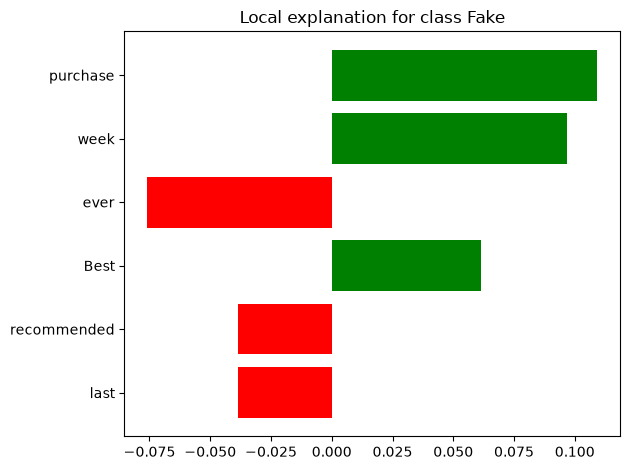

In [42]:
## 10. Interpretasi Model Menggunakan LIME
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=['Genuine', 'Fake'])

# Wrapper prediction function for LIME
def predict_proba_for_lime(texts):
    cleaned = [preprocess_text(t) for t in texts]
    tfidf_feats = loaded_vectorizer.transform(cleaned)
    dec_vals = loaded_model.decision_function(tfidf_feats)
    probs = 1 / (1 + np.exp(-dec_vals))
    return np.vstack([1 - probs, probs]).T

# Generate LIME explanation for the first sample review
sample_to_explain = sample_reviews[0]
exp = explainer.explain_instance(sample_to_explain, predict_proba_for_lime, num_features=6)

# Save and display LIME visualization
html_path = os.path.join(FIGURES_DIR, 'lime_explanation.html')
png_path = os.path.join(FIGURES_DIR, 'lime_explanation.png')

exp.save_to_file(html_path)
print(f"Saved LIME explanation to HTML: {html_path}")

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.show()
